In [1]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json

url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
#Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
parameters = {
  'start':'1',
  'limit':'15',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
}

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  #print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)

#NOTE:
# I had to go in and put "jupyter notebook --NotebookApp.iopub_data_rate_limit=1e10"
# Into the Anaconda Prompt to change this to allow to pull data

# If that didn't work try using the local host URL as shown in the video

In [2]:
type(data)

dict

In [3]:
import pandas as pd


#This allows you to see all the columns, not just like 15
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [41]:
#This normalizes the data and makes it all pretty in a dataframe

df = pd.json_normalize(data['data'])
df['timestamp'] = pd.to_datetime('now')
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,20076906.00000,20076906.00000,21000000.00000,2010-07-13T00:00:00.000Z,12718,1,2026-08-29T20:57:00.000Z,None,NaN,NaN,NaN,1569014364966.61011,"[mineable, pow, sha-256, store-of-value, state...",78150.20726,15101155060.21385,15066848448.17618,34306612.03767,-61.57800,-0.01565,0.98636,1.10729,20.72321,33.21349,6.10953,1569014364966.60815,59.54640,1641154352383.71997,None,2026-08-29T20:57:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-30 00:30:51.257601
1,1027,Ethereum,ETH,ethereum,True,120681171.50403,120681171.50403,NaN,2015-08-07T00:00:00.000Z,12855,2,2026-08-29T20:56:00.000Z,None,NaN,NaN,NaN,296054736322.65002,"[pos, smart-contracts, ethereum-ecosystem, coi...",2453.19740,6272683136.73802,6181341922.69102,91341214.04700,-63.19240,0.01873,1.04433,0.94468,27.71034,55.84244,22.42418,296054736322.64612,11.23570,296054736322.65002,None,2026-08-29T20:56:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-30 00:30:51.257601
2,825,Tether USDt,USDT,tether,True,183411465211.78317,189340270222.58569,NaN,2015-02-25T00:00:00.000Z,196663,3,2026-08-29T20:56:00.000Z,None,NaN,NaN,NaN,189356218587.23001,"[stablecoin, asset-backed-stablecoin, usd-stab...",1.00008,37617198653.96144,36684010104.95789,933188549.00356,-54.12230,0.01068,0.01375,0.01733,0.10816,0.16386,0.15007,183426914185.86804,6.96130,189356218587.23001,None,2026-08-29T20:56:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-08-30 00:30:51.257601
3,1839,BNB,BNB,bnb,False,133162513.38000,133162513.38000,133162513.85000,2017-07-25T00:00:00.000Z,3403,4,2026-08-29T20:57:00.000Z,None,NaN,NaN,NaN,92216903339.08000,"[marketplace, centralized-exchange, payments, ...",692.51399,969159991.46788,942135232.46957,27024758.99831,-34.59350,-0.09910,0.57143,-0.79442,16.91217,27.08186,-2.35640,92216903339.07556,3.49980,92216903664.56000,None,2026-08-29T20:57:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-30 00:30:51.257601
4,52,XRP,XRP,xrp,False,62744504852.00000,99985627691.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1867,5,2026-08-29T20:56:00.000Z,None,NaN,NaN,NaN,139818167161.67999,"[medium-of-exchange, enterprise-solutions, xrp...",1.39838,1340632606.48450,1339668581.54533,964024.93917,-64.64810,0.01815,1.29374,-6.90022,28.83866,34.26266,5.30810,87740827061.52161,3.32990,139838265149.25000,None,2026-08-29T20:56:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-30 00:30:51.257601
5,3408,USDC,USDC,usd-coin,False,74054301075.44373,74054301075.44373,NaN,2018-10-08T00:00:00.000Z,43906,6,2026-08-29T20:56:00.000Z,None,NaN,60901219650.23000,60903919714.35902,74057584283.28999,"[medium-of-exchange, stablecoin, asset-backed-...",1.00004,6815310484.82573,5865174253.91675,950136230.90899,-62.12680,0.00888,0.00238,0.00757,0.03293,0.04117,0.03976,74057584283.28557,2.81060,74057584283.28999,None,2026-08-29T20:56:00.000Z,24091.00000,zksync,zkSync Era,ZK,0x1d17CBcF0D6D143135aE902365D2E5e2A16538D4,2026-08-30 00:30:51.257601
6,5426,Solana,SOL,solana,True,584161267.24259,633078807.37361,NaN,2020-04-10T00:00:00.000Z,1166,7,2026-08-29T20:56:00.000Z,None,NaN,525236893.30000,55280447607.25774,66630658068.21000,"[pos, platform, solana-ecosystem, cms-holdings...",105.24860,2246134614.29641,2246103240.96386,31373.33255,-63.79130,-0.11992,1.35760,11.44004,41.38243,43.10350,28.69056,6148

In [7]:

def api_runner():
    global df
    url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
    #Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
    parameters = {
      'start':'1',
      'limit':'15',
      'convert':'USD'
    }
    headers = {
      'Accepts': 'application/json',
      'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
    }

    session = Session()
    session.headers.update(headers)

    try:
      response = session.get(url, params=parameters)
      data = json.loads(response.text)
      #print(data)
    except (ConnectionError, Timeout, TooManyRedirects) as e:
      print(e)

#NOTE:
# I had to go in and put "jupyter notebook --NotebookApp.iopub_data_rate_limit=1e10"
# Into the Anaconda Prompt to change this to allow to pull data
    
    # Use this if you just want to keep it in a dataframe
    df2 = pd.json_normalize(data['data'])
    df2['Timestamp'] = pd.to_datetime('now')
    df = pd.concat([df, df2], ignore_index=True)


    # Use this if you want to create a csv and append data to it
    #df = pd.json_normalize(data['data'])
    #df['timestamp'] = pd.to_datetime('now')
    #df

    #if not os.path.isfile(r'C:\Users\alexf\OneDrive\Documents\Python Scripts\API.csv'):
        #df.to_csv(r'C:\Users\alexf\OneDrive\Documents\Python Scripts\API.csv', header='column_names')
    #else:
        #df.to_csv(r'C:\Users\alexf\OneDrive\Documents\Python Scripts\API.csv', mode='a', header=False)
        
    #Then to read in the file: df = pd.read_csv(r'C:\Users\alexf\OneDrive\Documents\Python Scripts\API.csv')

# If that didn't work try using the local host URL as shown in the video

In [8]:
import os 
from time import time
from time import sleep

for i in range(333):
    api_runner()
    print('API Runner completed')
    sleep(60) #sleep for 1 minute
exit()

API Runner completed
API Runner completed
API Runner completed
API Runner completed
API Runner completed


KeyboardInterrupt: 

In [68]:
df72 = pd.read_csv(r'C:\Users\alexf\OneDrive\Documents\Python Scripts\API.csv')
df72

In [9]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp,Timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.007691e+07,2.007691e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12718,1,2026-08-29T20:57:00.000Z,None,NaN,NaN,NaN,1.569014e+12,"[mineable, pow, sha-256, store-of-value, state...",78150.207256,1.510116e+10,1.506685e+10,3.430661e+07,-61.5780,-0.015651,0.986362,1.107286,20.723212,33.213485,6.109532,1.569014e+12,59.5464,1.641154e+12,None,2026-08-29T20:57:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-29 23:58:08.122024,NaT
1,1027,Ethereum,ETH,ethereum,True,1.206812e+08,1.206812e+08,NaN,2015-08-07T00:00:00.000Z,12855,2,2026-08-29T20:56:00.000Z,None,NaN,NaN,NaN,2.960547e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",2453.197401,6.272683e+09,6.181342e+09,9.134121e+07,-63.1924,0.018733,1.044330,0.944680,27.710336,55.842436,22.424184,2.960547e+11,11.2357,2.960547e+11,None,2026-08-29T20:56:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-29 23:58:08.122024,NaT
2,825,Tether USDt,USDT,tether,True,1.834115e+11,1.893403e+11,NaN,2015-02-25T00:00:00.000Z,196663,3,2026-08-29T20:56:00.000Z,None,NaN,NaN,NaN,1.893562e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",1.000084,3.761720e+10,3.668401e+10,9.331885e+08,-54.1223,0.010685,0.013748,0.017328,0.108159,0.163859,0.150071,1.834269e+11,6.9613,1.893562e+11,None,2026-08-29T20:56:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-08-29 23:58:08.122024,NaT
3,1839,BNB,BNB,bnb,False,1.331625e+08,1.331625e+08,1.331625e+08,2017-07-25T00:00:00.000Z,3403,4,2026-08-29T20:57:00.000Z,None,NaN,NaN,NaN,9.221690e+10,"[marketplace, centralized-exchange, payments, ...",692.513989,9.691600e+08,9.421352e+08,2.702476e+07,-34.5935,-0.099104,0.571434,-0.794420,16.912169,27.081857,-2.356396,9.221690e+10,3.4998,9.221690e+10,None,2026-08-29T20:57:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-29 23:58:08.122024,NaT
4,52,XRP,XRP,xrp,False,6.274450e+10,9.998563e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1867,5,2026-08-29T20:56:00.000Z,None,NaN,NaN,NaN,1.398182e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.398383,1.340633e+09,1.339669e+09,9.640249e+05,-64.6481,0.018153,1.293739,-6.900221,28.838664,34.262665,5.308101,8.774083e+10,3.3299,1.398383e+11,None,2026-08-29T20:56:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-29 23:58:08.122024,NaT
5,3408,USDC,USDC,usd-coin,False,7.405430e+10,7.405430e+10,NaN,2018-10-08T00:00:00.000Z,43906,6,2026-08-29T20:56:00.000Z,None,NaN,6.090122e+10,6.090392e+10,7.405758e+10,"[medium-of-exchange, stablecoin, asset-backed-...",1.000044,6.815310e+09,5.865174e+09,9.501362e+08,-62.1268,0.008882,0.002384,0.007567,0.032933,0.041167,0.039764,7.405758e+10,2.8106,7.405758e+10,None,2026-08-29T20:56:00.000Z,24091.0,zksync,zkSync Era,ZK,0x1d17CBcF0D6D143135aE902365D2E5e2A16538D4,2026-08-29 23:58:08.122024,NaT
6,5426,Solana,SOL,solana,True,5.841613e+08,6.330788e+08,NaN,2020-04-10T00:00:00.000Z,1166,7,2026-08-29T20:56:00.000Z,None,NaN,5.252369e+08,5.528045e+10,6.663066e+10,"[pos, platform, solana-ecosystem, cms-holdings...",105.248600,2.246135e+09,2.246103e+09,3.137333e+04,-63.7913,-0.119921,1.357598,11.440044,41.382426,43.103501,28.690562,6.148216e+10,2.3333,6.663066e+10,None,2026-08-29T20:56:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-29 23:58:08.122024,NaT
7,1958,TRON,TRX,tron,True,9.492598e+10,9.492598e+10,NaN,2017-09-13T00:00:00.000Z,1366,8,2

In [10]:
# One thing I noticed was the scientific notation. I like it, but I want to be able to see the numbers in this case

pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [11]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp,Timestamp
0,1,Bitcoin,BTC,bitcoin,False,20076906.00000,20076906.00000,21000000.00000,2010-07-13T00:00:00.000Z,12718,1,2026-08-29T20:57:00.000Z,None,NaN,NaN,NaN,1569014364966.61011,"[mineable, pow, sha-256, store-of-value, state...",78150.20726,15101155060.21385,15066848448.17618,34306612.03767,-61.57800,-0.01565,0.98636,1.10729,20.72321,33.21349,6.10953,1569014364966.60815,59.54640,1641154352383.71997,None,2026-08-29T20:57:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-29 23:58:08.122024,NaT
1,1027,Ethereum,ETH,ethereum,True,120681171.50403,120681171.50403,NaN,2015-08-07T00:00:00.000Z,12855,2,2026-08-29T20:56:00.000Z,None,NaN,NaN,NaN,296054736322.65002,"[pos, smart-contracts, ethereum-ecosystem, coi...",2453.19740,6272683136.73802,6181341922.69102,91341214.04700,-63.19240,0.01873,1.04433,0.94468,27.71034,55.84244,22.42418,296054736322.64612,11.23570,296054736322.65002,None,2026-08-29T20:56:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-29 23:58:08.122024,NaT
2,825,Tether USDt,USDT,tether,True,183411465211.78317,189340270222.58569,NaN,2015-02-25T00:00:00.000Z,196663,3,2026-08-29T20:56:00.000Z,None,NaN,NaN,NaN,189356218587.23001,"[stablecoin, asset-backed-stablecoin, usd-stab...",1.00008,37617198653.96144,36684010104.95789,933188549.00356,-54.12230,0.01068,0.01375,0.01733,0.10816,0.16386,0.15007,183426914185.86804,6.96130,189356218587.23001,None,2026-08-29T20:56:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-08-29 23:58:08.122024,NaT
3,1839,BNB,BNB,bnb,False,133162513.38000,133162513.38000,133162513.85000,2017-07-25T00:00:00.000Z,3403,4,2026-08-29T20:57:00.000Z,None,NaN,NaN,NaN,92216903339.08000,"[marketplace, centralized-exchange, payments, ...",692.51399,969159991.46788,942135232.46957,27024758.99831,-34.59350,-0.09910,0.57143,-0.79442,16.91217,27.08186,-2.35640,92216903339.07556,3.49980,92216903664.56000,None,2026-08-29T20:57:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-29 23:58:08.122024,NaT
4,52,XRP,XRP,xrp,False,62744504852.00000,99985627691.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1867,5,2026-08-29T20:56:00.000Z,None,NaN,NaN,NaN,139818167161.67999,"[medium-of-exchange, enterprise-solutions, xrp...",1.39838,1340632606.48450,1339668581.54533,964024.93917,-64.64810,0.01815,1.29374,-6.90022,28.83866,34.26266,5.30810,87740827061.52161,3.32990,139838265149.25000,None,2026-08-29T20:56:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-29 23:58:08.122024,NaT
5,3408,USDC,USDC,usd-coin,False,74054301075.44373,74054301075.44373,NaN,2018-10-08T00:00:00.000Z,43906,6,2026-08-29T20:56:00.000Z,None,NaN,60901219650.23000,60903919714.35902,74057584283.28999,"[medium-of-exchange, stablecoin, asset-backed-...",1.00004,6815310484.82573,5865174253.91675,950136230.90899,-62.12680,0.00888,0.00238,0.00757,0.03293,0.04117,0.03976,74057584283.28557,2.81060,74057584283.28999,None,2026-08-29T20:56:00.000Z,24091.00000,zksync,zkSync Era,ZK,0x1d17CBcF0D6D143135aE902365D2E5e2A16538D4,2026-08-29 23:58:08.122024,NaT
6,5426,Solana,SOL,solana,True,584161267.24259,633078807.37361,NaN,2020-04-10T00:00:00.000Z,1166,7,2026-08-29T20:56:00.000Z,None,NaN,525236893.30000,55280447607.25774,66630658068.21000,"[pos, platform, solana-ecosystem, cms-holdings...",105.24860,2246134614.29641,2246103240.96386,31373.33255,-63.79130,-0.11992,1.35760,11.440

In [12]:
# Now let's look at the coin trends over time

df3 = df.groupby('name', sort=False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d']].mean()
df3

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,-0.19118,0.93836,1.23245,20.66742,33.17852,6.07270
Ethereum,-0.11919,0.98778,1.16003,27.61921,55.75880,22.34597
Tether USDt,-0.00076,0.01321,0.00394,0.10285,0.16583,0.14451
BNB,-0.11097,0.64274,-0.46020,16.95411,27.14284,-2.23509
XRP,-0.15972,1.23557,-6.37683,28.70259,34.19246,5.13559
USDC,0.00351,0.00855,0.00213,0.03464,0.05332,0.04278
Solana,-0.25888,1.30260,11.96968,41.22759,42.89587,28.53770
TRON,0.15055,-0.48241,-1.52171,3.36660,7.97424,-2.82789
Hyperliquid,-0.14200,3.76159,5.12918,50.29790,27.90834,18.33681


In [13]:
df4 = df3.stack()
df4

name                                      
Bitcoin       quote.USD.percent_change_1h     -0.19118
              quote.USD.percent_change_24h     0.93836
              quote.USD.percent_change_7d      1.23245
              quote.USD.percent_change_30d    20.66742
              quote.USD.percent_change_60d    33.17852
              quote.USD.percent_change_90d     6.07270
Ethereum      quote.USD.percent_change_1h     -0.11919
              quote.USD.percent_change_24h     0.98778
              quote.USD.percent_change_7d      1.16003
              quote.USD.percent_change_30d    27.61921
              quote.USD.percent_change_60d    55.75880
              quote.USD.percent_change_90d    22.34597
Tether USDt   quote.USD.percent_change_1h     -0.00076
              quote.USD.percent_change_24h     0.01321
              quote.USD.percent_change_7d      0.00394
              quote.USD.percent_change_30d     0.10285
              quote.USD.percent_change_60d     0.16583
              quote.US

In [14]:
type(df4)

pandas.Series

In [20]:
df5 = df4.to_frame(name='values')
df5

values
name                                               
Bitcoin      quote.USD.percent_change_1h   -0.19118
             quote.USD.percent_change_24h   0.93836
             quote.USD.percent_change_7d    1.23245
             quote.USD.percent_change_30d  20.66742
             quote.USD.percent_change_60d  33.17852
             quote.USD.percent_change_90d   6.07270
Ethereum     quote.USD.percent_change_1h   -0.11919
             quote.USD.percent_change_24h   0.98778
             quote.USD.percent_change_7d    1.16003
             quote.USD.percent_change_30d  27.61921
             quote.USD.percent_change_60d  55.75880
             quote.USD.percent_change_90d  22.34597
Tether USDt  quote.USD.percent_change_1h   -0.00076
             quote.USD.percent_change_24h   0.01321
             quote.USD.percent_change_7d    0.00394
             quote.USD.percent_change_30d   0.10285
             quote.USD.percent_change_60d   0.16583
             quote.USD.percent_change_90d   0.14451
BNB          quote.USD.percent_change_1h   -0.11097
             quote.USD.percent_change_24h   0.64274
             quote.USD.percent_change_7d   -0.46020
             quote.USD.percent_change_30d  16.95411
             quote.USD.percent_change_60d  27.14284
             quote.USD.percent_change_90d  -2.23509
XRP          quote.USD.percent_change_1h   -0.15972
             quote.USD.percent_change_24h   1.23557
             quote.USD.percent_change_7d   -6.37683
             quote.USD.percent_change_30d  28.70259
             quote.USD.percent_change_60d  34.19246
             quote.USD.percent_change_90d   5.13559
USDC         quote.USD.percent_change_1h    0.00351
             quote.USD.percent_change_24h   0.00855
             quote.USD.percent_change_7d    0.00213
             quote.USD.percent_change_30d   0.03464
             quote.USD.percent_change_60d   0.05332
             quote.USD.percent_change_90d   0.04278
Solana       quote.USD.percent_change_1h   -0.25888
             quote.USD.percent_change_24h   1.30260
             quote.USD.percent_change_7d   11.96968
             quote.USD.percent_change_30d  41.22759
             quote.USD.percent_change_60d  42.89587
             quote.USD.percent_change_90d  28.53770
TRON         quote.USD.percent_change_1h    0.15055
             quote.USD.percent_change_24h  -0.48241
             quote.USD.percent_change_7d   -1.52171
             quote.USD.percent_change_30d   3.36660
             quote.USD.percent_change_60d   7.97424
             quote.USD.percent_change_90d  -2.82789
Hyperliquid  quote.USD.percent_change_1h   -0.14200
             quote.USD.percent_change_24h   3.76159
             quote.USD.percent_change_7d    5.12918
             quote.USD.percent_change_30d  50.29790
             quote.USD.percent_change_60d  27.90834
             quote.USD.percent_change_90d  18.33681
Zcash        quote.USD.percent_change_1h    0.52302
             quote.USD.percent_change_24h   5.33823
             quote.USD.percent_change_7d    1.52212
             quote.USD.percent_change_30d  77.55398
             quote.USD.percent_change_60d 110.97831
             quote.USD.percent_change_90d  53.22160
Dogecoin     quote.USD.percent_change_1h   -0.09504
             quote.USD.percent_change_24h   0.45735
             quote.USD.percent_change_7d   -9.23515
             quote.USD.percent_change_30d  20.77576
             quote.USD.percent_change_60d  18.34776
             quote.USD.percent_change_90d -14.53075
UNUS SED LEO quote.USD.percent_change_1h    0.21526
             quote.USD.percent_change_24h   2.91711
             quote.USD.percent_change_7d    2.99036
             quote.USD.percent_change_30d  -0.94261
             quote.USD.percent_change_60d   4.73452
             quote.USD.percent_change_90d  -3.36335
Monero       quote.USD.percent_change_1h    0.51598
             quote.USD.percent_change_24h  -0.16486
             quote.USD.percent_change_7d    9.32496
             quote.USD.percent_change_30d

In [21]:
df5.count()

values    90
dtype: int64

In [25]:
df6 = df5.reset_index()
df6

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,-0.19118
1,Bitcoin,quote.USD.percent_change_24h,0.93836
2,Bitcoin,quote.USD.percent_change_7d,1.23245
3,Bitcoin,quote.USD.percent_change_30d,20.66742
4,Bitcoin,quote.USD.percent_change_60d,33.17852
5,Bitcoin,quote.USD.percent_change_90d,6.07270
6,Ethereum,quote.USD.percent_change_1h,-0.11919
7,Ethereum,quote.USD.percent_change_24h,0.98778
8,Ethereum,quote.USD.percent_change_7d,1.16003
9,Ethereum,quote.USD.percent_change_30d,27.61921


In [23]:
#Because of how it's structured above we need to set an index. I don't want to pass a column as an index for this dataframe
#So I'm going to create a range and pass that as the dataframe. You can make this more dynamic, but I'm just going to hard code it


index = pd.Index(range(90))

# Set the above DataFrame index object as the index
# using set_index() function
df6 = df5.set_index(index)
df6

# If it only has the index and values try doing reset_index like "df5.reset_index()"

,values
0,-0.19118
1,0.93836
2,1.23245
3,20.66742
4,33.17852
5,6.07270
6,-0.11919
7,0.98778
8,1.16003
9,27.61921


In [32]:
# Change the column name

df7 = df6.rename(columns={'level_1': 'percent_change'})
df7

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,-0.19118
1,Bitcoin,quote.USD.percent_change_24h,0.93836
2,Bitcoin,quote.USD.percent_change_7d,1.23245
3,Bitcoin,quote.USD.percent_change_30d,20.66742
4,Bitcoin,quote.USD.percent_change_60d,33.17852
5,Bitcoin,quote.USD.percent_change_90d,6.07270
6,Ethereum,quote.USD.percent_change_1h,-0.11919
7,Ethereum,quote.USD.percent_change_24h,0.98778
8,Ethereum,quote.USD.percent_change_7d,1.16003
9,Ethereum,quote.USD.percent_change_30d,27.61921


In [34]:
df7['percent_change'] = df7['percent_change'].replace(['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d'],['1h','24h','7d','30d','60d','90d'])
df7

,name,percent_change,values
0,Bitcoin,1h,-0.19118
1,Bitcoin,24h,0.93836
2,Bitcoin,7d,1.23245
3,Bitcoin,30d,20.66742
4,Bitcoin,60d,33.17852
5,Bitcoin,90d,6.07270
6,Ethereum,1h,-0.11919
7,Ethereum,24h,0.98778
8,Ethereum,7d,1.16003
9,Ethereum,30d,27.61921


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

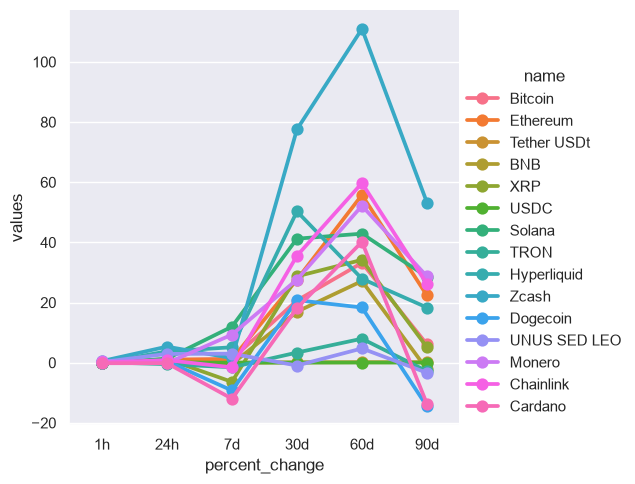

In [36]:
sns.catplot(x='percent_change', y='values', hue='name', data=df7, kind='point')

In [42]:
# Now to do something much simpler
# we are going to create a dataframe with the columns we want

df10 = df[['name','quote.USD.price','timestamp']]
df10 = df10.query("name == 'Bitcoin'")
df10

,name,quote.USD.price,timestamp
0,Bitcoin,78150.20726,2026-08-30 00:30:51.257601


<Axes: xlabel='timestamp', ylabel='quote.USD.price'>

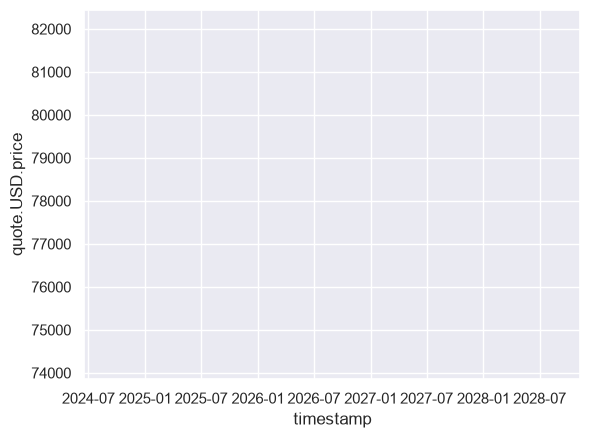

In [43]:
sns.set_theme(style="darkgrid")

sns.lineplot(x='timestamp', y='quote.USD.price', data = df10)